# 06. 군집은 업종을 얼마나 따라가나 — 시장 구조 마이닝

> 2026-09-09 · 이동원 · 수업 09단원 5장 *비지도학습_시장구조분석* 의 방법을 우리 후보군에 ·
> 앞 노트북: [05. 횡단면 전처리는 날짜 안에서 끝난다](05.횡단면-전처리는-날짜-안에서-끝난다.ipynb)

수업 5장은 10종목의 수익률 상관에서 거리(1 − 상관)를 만들어 **계층군집(ward)** 으로 묶고, 표준화한
수익률에 **PCA** 를 걸어 설명분산을 봤습니다. 같은 방법을 우리 개별종목 후보군(업종 10 × 종목 5 에
한 번이라도 든 KOSPI 종목)에 걸고, 여기에 물음을 하나 더합니다 —

> **자료가 스스로 찾는 군집은 손으로 받은 업종 스냅샷(17종)과 얼마나 맞는가?**

이 물음은 앞 노트북 05 의 6절의 결정과 이어집니다. 업종 더미가 피처 분산을 잡음 기대치보다 조금밖에
더 설명하지 못했는데, 수익률 자체의 구조에서도 업종이 약하게 보인다면 그 결정은 일관된 것입니다.

순서:

1. 수익률 표 — 종목 × 거래일
2. 상관 구조 — 업종 순서로 늘어놓은 히트맵
3. 계층군집 — 덴드로그램과 업종 일치도(ARI · NMI)
4. k 를 바꿔 가며 — 군집 수에 따른 일치도 · KMeans 와 비교
5. PCA — 설명분산 · PC1 은 시장인가 · PC2 는 무엇인가
6. 시간에 따른 시장 집중도 — 흡수비(absorption ratio)
7. 정리

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import scripts.run_stock_model_experiment as exp     # noqa: E402, I001

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)


def 한글폰트_설정() -> str:
    """한글 폰트를 잡고 **깨짐을 막는다** — 앞 노트북 05 와 같은 블록.

    맑은 고딕에는 U+2212(−)가 **없다**(실측). `font.family` 에 리스트를 주면
    matplotlib(3.6+)이 없는 글자만 뒤 폰트에서 찾으므로, DejaVu Sans 를 뒤에 두면
    둘이 서로를 채운다(한글은 맑은 고딕, 마이너스는 DejaVu).

    🔴 로그 축 눈금만은 이것으로도 안 고쳐진다 — mathtext 는 이 체인을 안 따른다.
    이 노트북에는 로그 축이 없어 문제가 없고, 쓰게 되면 05 의 `로그축_ASCII()` 를
    가져다 쓴다.
    """
    후보 = ["Malgun Gothic", "NanumGothic", "NanumBarunGothic", "AppleGothic",
            "Noto Sans CJK KR", "Gulim"]
    있는것 = {f.name for f in font_manager.fontManager.ttflist}
    찾음 = next((n for n in 후보 if n in 있는것), None)
    if 찾음 is None:
        print("🔴 한글 폰트가 없다 — 그림의 한글이 □ 로 나온다. 할 일:\n"
              "   Colab·Linux : !apt-get install -y fonts-nanum && fc-cache -fv → 런타임 재시작\n"
              "   Windows     : matplotlib 캐시 폴더를 지우고 다시 실행")
        return "(없음)"
    plt.rcParams["font.family"] = [찾음, "DejaVu Sans"]
    plt.rcParams["axes.unicode_minus"] = False
    return 찾음


폰트 = 한글폰트_설정()
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["grid.color"] = "#e1e0d9"
plt.rcParams["axes.edgecolor"] = "#c3c2b7"
C = {"blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
     "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
     "gray": "#898781", "light": "#c3c2b7"}
# 발산 팔레트 — 두 색 + 회색 가운데 (상관 −1 … 0 … +1)
DIV = LinearSegmentedColormap.from_list("div", [C["blue"], "#e1e0d9", C["orange"]])
HF = ROOT / "data" / "raw" / "hf_snapshot" / "full" / "daily_price_dev.parquet"
t0 = time.time()
print(f"한글 폰트: {폰트} · fallback {plt.rcParams['font.family']}")

한글 폰트: Malgun Gothic · fallback ['Malgun Gothic', 'DejaVu Sans']


## 1. 수익률 표 — 종목 × 거래일

후보군에 한 번이라도 든 종목의 **전 개발구간** 수정종가를 HF 반출본에서 읽어 일간 수익률 표를
만듭니다. 업종은 후보 패널이 붙여 둔 `industry`(그 종목이 마지막으로 후보였던 날의 업종)를 씁니다.
개발구간 안에 상장된 종목은 앞이 비므로, 거래일 커버리지가 낮은 종목은 뺍니다.

In [2]:
base = exp._read_cached_panel(exp._panel_cache_signature()).frame
last_ind = base.sort_values("bas_dd").groupby("code")[["industry", "name"]].last()
codes = last_ind.index.tolist()
px = pq.read_table(HF, columns=["bas_dd", "code", "adj_close"],
                   filters=[("code", "in", codes)]).to_pandas()
wide = px.pivot(index="bas_dd", columns="code", values="adj_close").sort_index()
rets = wide.pct_change(fill_method=None)
cover = rets.notna().mean()
keep = cover[cover >= 0.8].index
rets = rets.loc[:, keep]
ind = last_ind.loc[keep, "industry"]
names = last_ind.loc[keep, "name"]
print(f"후보 종목 {len(codes)}종 → 커버리지 80% 이상 {len(keep)}종 · 거래일 {len(rets):,}일 "
      f"({rets.index.min()}~{rets.index.max()}) · 업종 {ind.nunique()}종")
print(ind.value_counts().to_string())

후보 종목 164종 → 커버리지 80% 이상 131종 · 거래일 3,618일 (20100104~20240830) · 업종 17종
industry
화학         13
일반서비스      13
제약         12
금속         12
유통         12
음식료·담배      9
운송장비·부품     9
보험          8
전기·전자       7
운송·창고       6
건설          6
전기·가스       6
기계·장비       5
섬유·의류       4
통신          4
증권          3
비금속         2


## 2. 상관 구조 — 업종 순서로 늘어놓은 히트맵

수업 5장의 `returns_df.corr()` 입니다. 종목을 업종별로 모아 놓으면 대각선 근처의 블록이 "같은
업종끼리 같이 움직이는가" 를 보여 줍니다. 결측은 쌍별(pairwise)로 뺍니다.

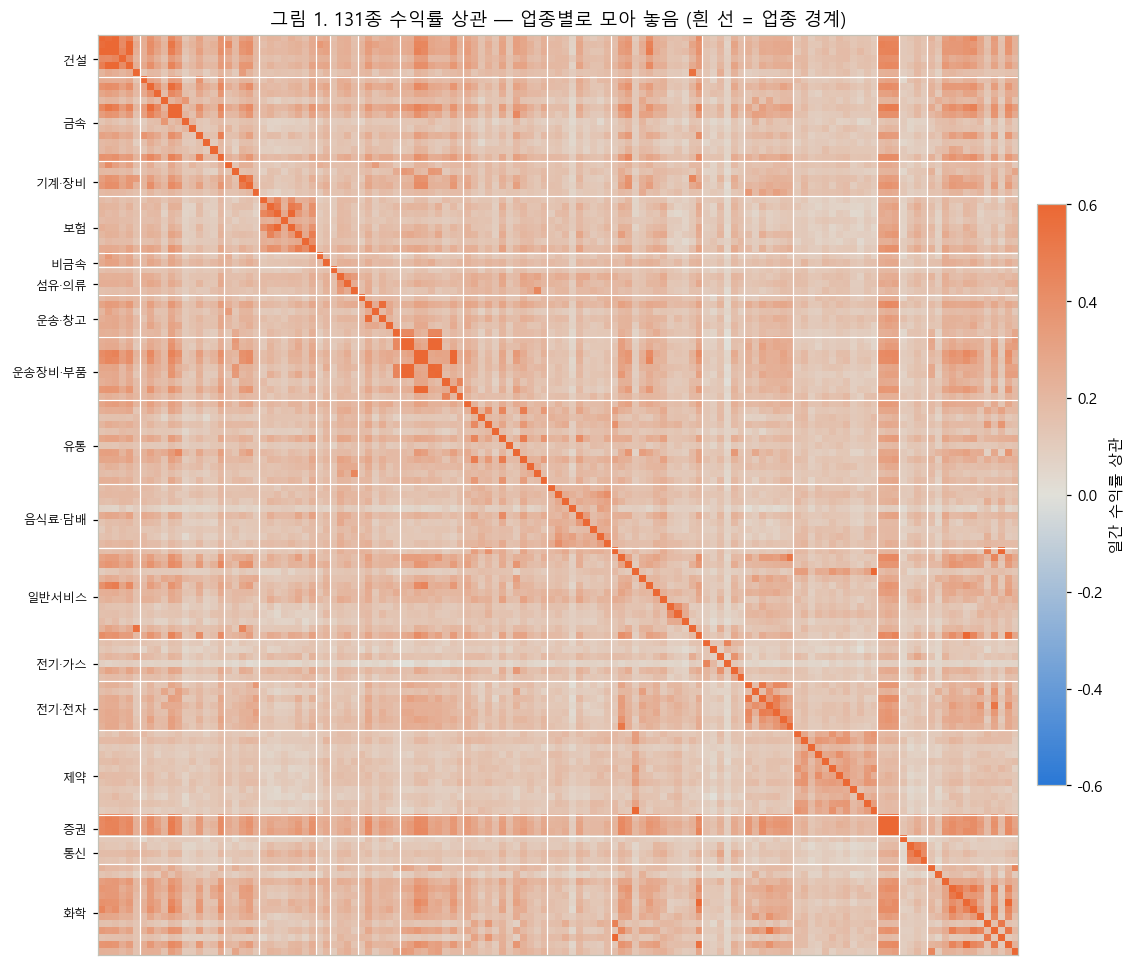

평균 상관 — 같은 업종 0.258 · 다른 업종 0.172 · 전체 0.177


In [3]:
corr = rets.corr(min_periods=250)
order = ind.sort_values(kind="stable").index
cm = corr.loc[order, order]
bounds = ind.loc[order].ne(ind.loc[order].shift()).to_numpy().nonzero()[0]
fig, ax = plt.subplots(figsize=(10, 9))
im = ax.imshow(cm.to_numpy(), cmap=DIV, vmin=-0.6, vmax=0.6, interpolation="nearest")
for b in bounds[1:]:
    ax.axhline(b - 0.5, color="white", lw=0.8)
    ax.axvline(b - 0.5, color="white", lw=0.8)
mids = [(bounds[i] + (bounds[i + 1] if i + 1 < len(bounds) else len(order))) / 2
        for i in range(len(bounds))]
ax.set_yticks(mids)
ax.set_yticklabels(ind.loc[order].unique(), fontsize=8)
ax.set_xticks([])
ax.grid(False)
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="일간 수익률 상관")
ax.set_title(f"그림 1. {len(order)}종 수익률 상관 — 업종별로 모아 놓음 (흰 선 = 업종 경계)")
plt.tight_layout()
plt.show()
off = cm.to_numpy()[~np.eye(len(cm), dtype=bool)]
same = (ind.loc[order].to_numpy()[:, None] == ind.loc[order].to_numpy()[None, :])
same_off = same[~np.eye(len(cm), dtype=bool)]
print(f"평균 상관 — 같은 업종 {off[same_off].mean():.3f} · 다른 업종 {off[~same_off].mean():.3f} "
      f"· 전체 {off.mean():.3f}")

## 3. 계층군집 — 덴드로그램과 업종 일치도

수업과 같이 거리 = 1 − 상관, `linkage(…, "ward")`. 업종 수(17)만큼 자른 군집이 업종 라벨과
얼마나 맞는지를 **ARI**(조정 랜드 지수 · 무작위면 0 · 완전 일치 1)와 **NMI** 로 잽니다.

업종 수 k=17 로 자른 계층군집 ↔ 업종: ARI 0.363 · NMI 0.667


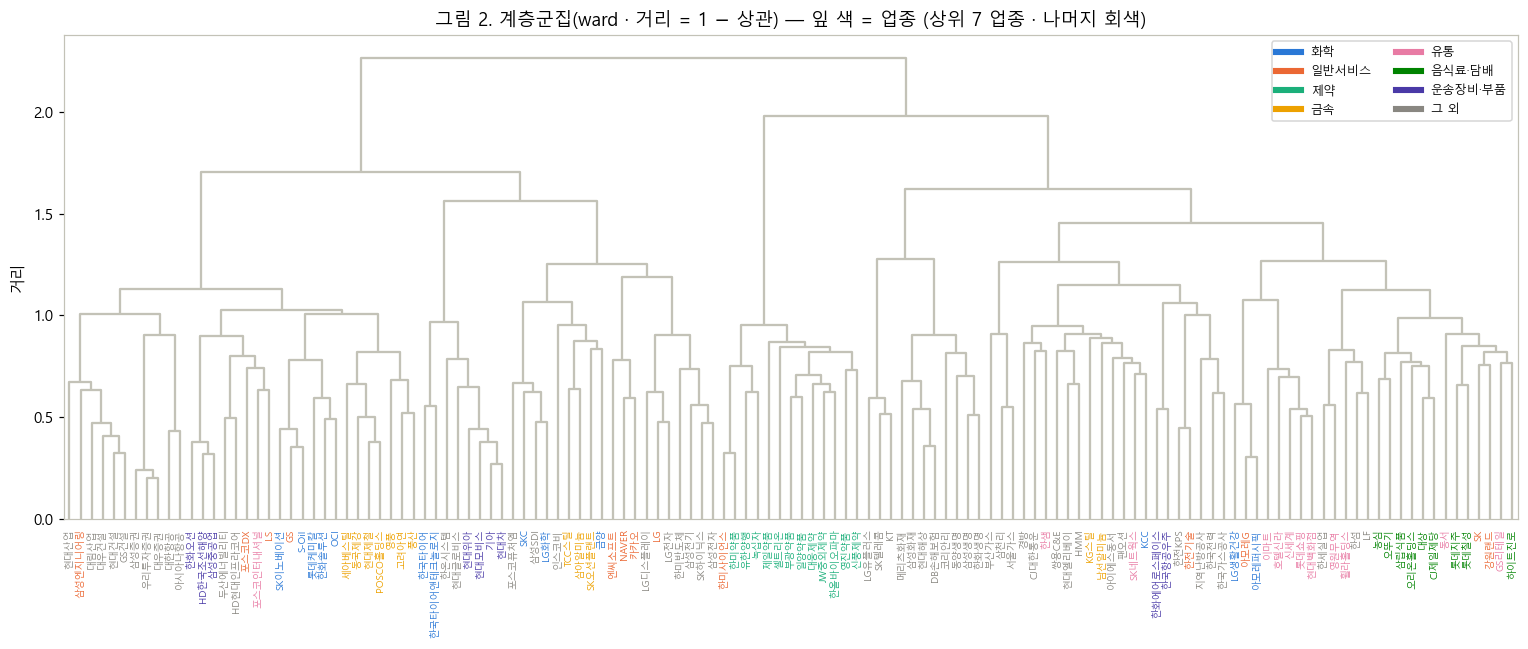

In [4]:
dist = 1 - corr.loc[order, order]
Z = linkage(squareform(dist.to_numpy(), checks=False), "ward")
k_ind = ind.nunique()
labels_k = fcluster(Z, t=k_ind, criterion="maxclust")
ari = adjusted_rand_score(ind.loc[order], labels_k)
nmi = normalized_mutual_info_score(ind.loc[order], labels_k)
print(f"업종 수 k={k_ind} 로 자른 계층군집 ↔ 업종: ARI {ari:.3f} · NMI {nmi:.3f}")

top7 = ind.value_counts().head(7).index.tolist()
palette = [C["blue"], C["orange"], C["aqua"], C["yellow"], C["magenta"], C["green"], C["violet"]]
color_of = {i: palette[n] for n, i in enumerate(top7)}
fig, ax = plt.subplots(figsize=(14, 6))
dn = dendrogram(Z, labels=[f"{names[c]}" for c in order], leaf_rotation=90, leaf_font_size=6.5,
                color_threshold=0, above_threshold_color=C["light"], ax=ax)
for lbl in ax.get_xmajorticklabels():
    c = order[list(names[order]).index(lbl.get_text())]
    lbl.set_color(color_of.get(ind[c], C["gray"]))
ax.set_title("그림 2. 계층군집(ward · 거리 = 1 − 상관) — 잎 색 = 업종 (상위 7 업종 · 나머지 회색)")
ax.set_ylabel("거리")
ax.grid(False)
handles = [plt.Line2D([], [], color=color_of[i], lw=4, label=i) for i in top7]
handles.append(plt.Line2D([], [], color=C["gray"], lw=4, label="그 외"))
ax.legend(handles=handles, loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 4. k 를 바꿔 가며 — 군집 수에 따른 일치도 · KMeans 와 비교

k=17 하나로 판단하면 우연에 기댑니다. k 를 2~30 으로 바꾸며 ARI 를 보고, 수업 22장의 KMeans(표준화
수익률 · 종목 = 관측, 거래일 = 변수)도 같은 k 로 비교합니다. 라벨을 무작위로 섞은 기준선도 함께
그립니다 — 그 선 위로 얼마나 올라오는지가 "업종이 구조에 있다" 의 크기입니다.

C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


...

C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\kik32\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


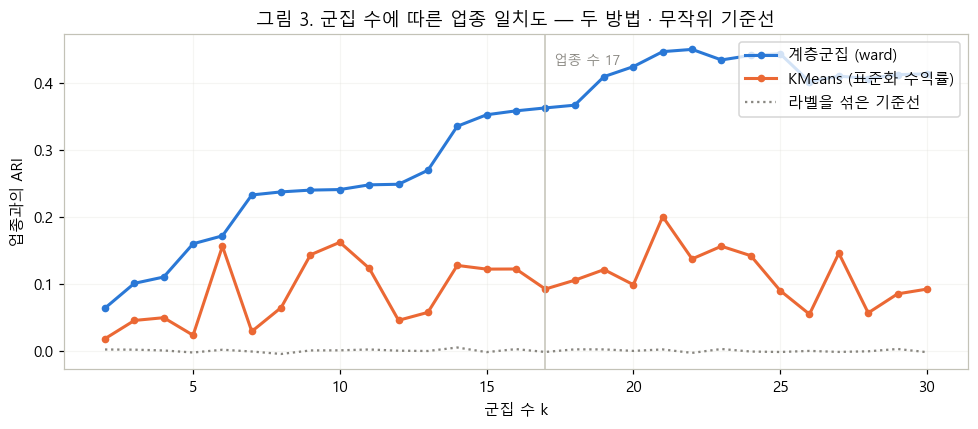

계층군집 최대 ARI 0.451 (k=22) · KMeans 최대 0.201 (k=21) · 기준선 평균 0.000


In [5]:
X = StandardScaler().fit_transform(rets.loc[:, order].fillna(0.0).to_numpy().T)   # 종목 × 거래일
ks = list(range(2, 31))
ari_h, ari_km, ari_rand = [], [], []
rng = np.random.default_rng(0)
y_ind = ind.loc[order].to_numpy()
for k in ks:
    lab_h = fcluster(Z, t=k, criterion="maxclust")
    ari_h.append(adjusted_rand_score(y_ind, lab_h))
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(X)
    ari_km.append(adjusted_rand_score(y_ind, km.labels_))
    ari_rand.append(np.mean([adjusted_rand_score(rng.permutation(y_ind), lab_h)
                             for _ in range(20)]))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ks, ari_h, color=C["blue"], lw=2, marker="o", ms=4, label="계층군집 (ward)")
ax.plot(ks, ari_km, color=C["orange"], lw=2, marker="o", ms=4, label="KMeans (표준화 수익률)")
ax.plot(ks, ari_rand, color=C["gray"], lw=1.5, ls=":", label="라벨을 섞은 기준선")
ax.axvline(k_ind, color=C["light"], lw=1)
ax.text(k_ind + 0.3, max(max(ari_h), max(ari_km)) * 0.95, f"업종 수 {k_ind}",
        color=C["gray"], fontsize=9)
ax.set_xlabel("군집 수 k")
ax.set_ylabel("업종과의 ARI")
ax.set_title("그림 3. 군집 수에 따른 업종 일치도 — 두 방법 · 무작위 기준선")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
best = int(np.argmax(ari_h))
print(f"계층군집 최대 ARI {ari_h[best]:.3f} (k={ks[best]}) · KMeans 최대 {max(ari_km):.3f} "
      f"(k={ks[int(np.argmax(ari_km))]}) · 기준선 평균 {np.mean(ari_rand):.3f}")

## 5. PCA — 설명분산 · PC1 은 시장인가 · PC2 는 무엇인가

수업 5장·23장의 PCA 입니다. 표준화한 수익률(거래일 × 종목)에 걸어 설명분산을 보고, PC1 적재값이
전부 같은 부호면 그것은 "시장" 입니다. PC2 적재값을 업종별로 모으면 두 번째 축이 무엇을 가르는지가
보입니다.

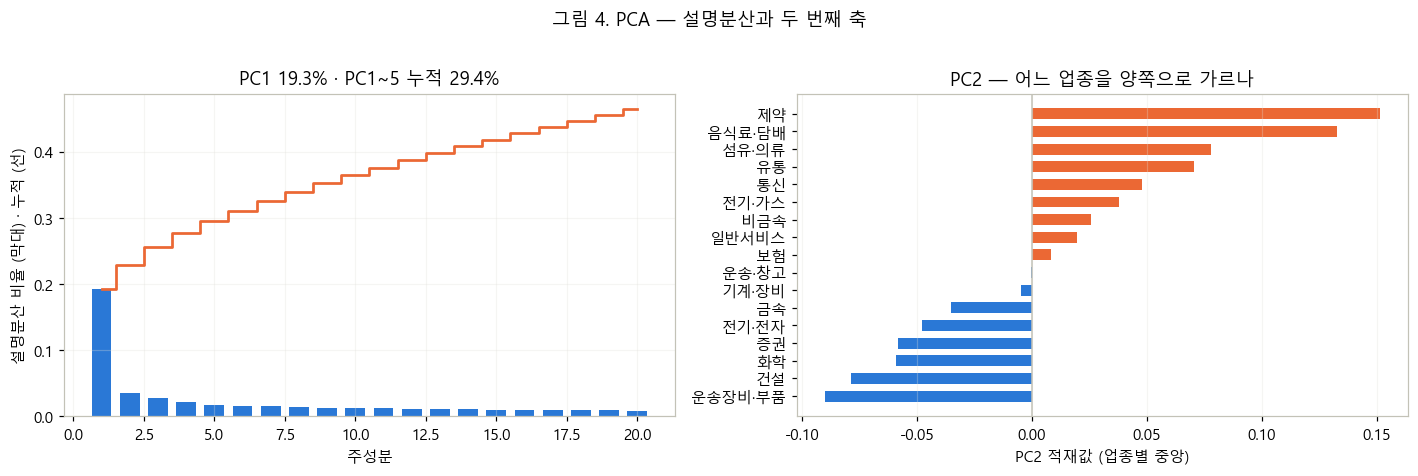

PC1 적재값 부호: 양 131종 · 음 0종 → 전부 같은 부호 = 시장


In [6]:
R = rets.loc[:, order].fillna(0.0)
Xs = StandardScaler().fit_transform(R.to_numpy())               # 거래일 × 종목
pca = PCA().fit(Xs)
ev = pca.explained_variance_ratio_
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
ax = axes[0]
ax.bar(range(1, 21), ev[:20], color=C["blue"], width=0.7)
ax.step(range(1, 21), np.cumsum(ev[:20]), where="mid", color=C["orange"], lw=1.8)
ax.set_xlabel("주성분")
ax.set_ylabel("설명분산 비율 (막대) · 누적 (선)")
ax.set_title(f"PC1 {ev[0]:.1%} · PC1~5 누적 {ev[:5].sum():.1%}")
ax = axes[1]
load = pd.DataFrame(pca.components_[:2].T, index=order, columns=["PC1", "PC2"])
load["업종"] = ind.loc[order].to_numpy()
grp = load.groupby("업종")["PC2"].median().sort_values()
ax.barh(grp.index, grp.values, color=[C["orange"] if v > 0 else C["blue"] for v in grp.values],
        height=0.62)
ax.axvline(0, color=C["light"], lw=1)
ax.set_xlabel("PC2 적재값 (업종별 중앙)")
ax.set_title("PC2 — 어느 업종을 양쪽으로 가르나")
ax.grid(axis="y", visible=False)
fig.suptitle("그림 4. PCA — 설명분산과 두 번째 축", y=1.02)
plt.tight_layout()
plt.show()
one_sign = load["PC1"].gt(0).all() or load["PC1"].lt(0).all()
print(f"PC1 적재값 부호: 양 {int((load['PC1'] > 0).sum())}종 · 음 {int((load['PC1'] < 0).sum())}종 "
      f"→ {'전부 같은 부호 = 시장' if one_sign else '섞임'}")

## 6. 시간에 따른 시장 집중도 — 흡수비

PC1 설명분산을 **굴려 가며**(250거래일 창) 보면 시장이 "한 덩어리로 움직이는 정도" 가 시간에 따라
어떻게 변했는지가 보입니다. Kritzman 등(2011)이 *absorption ratio* 라 부른 지표이고, 위기 국면에서
오릅니다. 이것은 앞 노트북 5절(그날 표준편차가 시간에 따라 크게 움직인다)과 같은 현상의 다른 얼굴입니다.

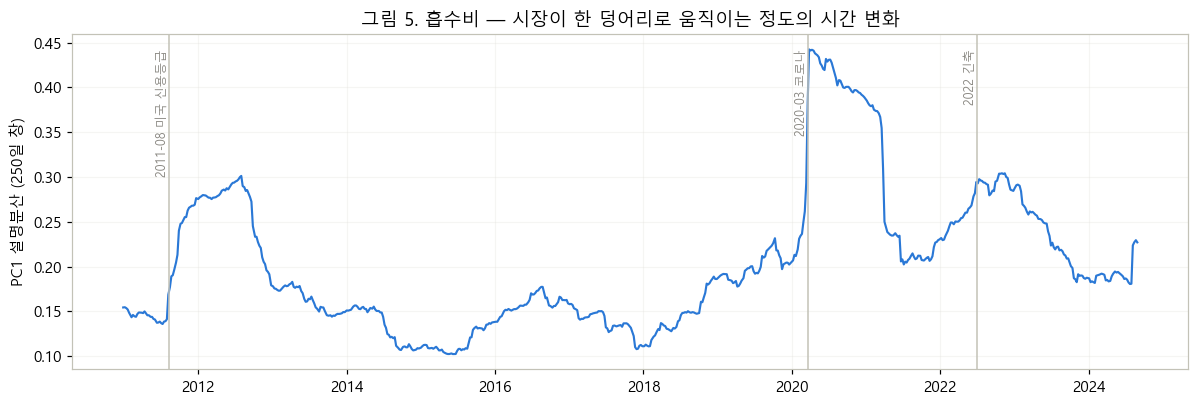

흡수비 최소 0.103 (2015-06) · 최대 0.442 (2020-03)


In [7]:
win = 250
dates = pd.to_datetime(R.index)
absorb = []
for end in range(win, len(R) + 1, 5):
    block = R.iloc[end - win:end].to_numpy()
    block = (block - block.mean(0)) / (block.std(0) + 1e-12)
    ev1 = PCA(n_components=1).fit(block).explained_variance_ratio_[0]
    absorb.append((dates[end - 1], ev1))
ab = pd.Series(dict(absorb))
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.plot(ab.index, ab.values, color=C["blue"], lw=1.4)
events = ((pd.Timestamp("2020-03-19"), "2020-03 코로나"),
          (pd.Timestamp("2011-08-09"), "2011-08 미국 신용등급"),
          (pd.Timestamp("2022-06-30"), "2022 긴축"))
for d, txt in events:
    if ab.index.min() <= d <= ab.index.max():
        ax.axvline(d, color=C["light"], lw=1)
        ax.text(d, ab.max(), txt, fontsize=8, color=C["gray"], rotation=90, va="top", ha="right")
ax.set_ylabel("PC1 설명분산 (250일 창)")
ax.set_title("그림 5. 흡수비 — 시장이 한 덩어리로 움직이는 정도의 시간 변화")
plt.tight_layout()
plt.show()
print(f"흡수비 최소 {ab.min():.3f} ({ab.idxmin():%Y-%m}) · "
      f"최대 {ab.max():.3f} ({ab.idxmax():%Y-%m})")

## 7. 정리

| 물음 | 답 (이 노트북) |
|---|---|
| 같은 업종은 더 같이 움직이나 | 2절 — 같은 업종 평균 상관 vs 다른 업종 |
| 자료가 찾는 군집이 업종과 맞나 | 3·4절 — ARI 가 무작위 기준선 위로 얼마나 오르나 · k 에 따른 곡선 |
| 시장 요인은 얼마나 큰가 | 5절 — PC1 설명분산 · 적재값 부호 |
| 그 크기는 시간에 따라 변하나 | 6절 — 흡수비 |

앞 노트북 05 의 6절의 "업종 R² 는 잡음 기대치 근처" 와 여기의 ARI 를 나란히 놓으면, **업종 중립화의
기본값**을 IC 표가 정한 이유가 수익률 구조 쪽에서도 설명됩니다. 수업 5장의 방법을 그대로 썼고
(상관 → 거리 → ward · 표준화 → PCA), 더한 것은 업종 라벨과의 일치도(ARI·NMI)와 시간축(흡수비)뿐입니다.

In [8]:
now_kst = pd.Timestamp.now(tz="Asia/Seoul")
print(f"총 {time.time() - t0:,.0f}초 · 실행일 {now_kst:%Y-%m-%d %H:%M} KST")

총 17초 · 실행일 2026-09-09 12:19 KST
